# **LSTM and GRU Lab**


In [1]:
%%capture

!mamba install -qy tqdm
!pip install tensorflow --upgrade

In [7]:
# You can also use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import tensorflow as tf
print(tf. __version__)

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding,Masking,LSTM, GRU, Conv1D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing import sequence

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, SimpleRNN



sns.set_context('notebook')
sns.set_style('white')
np.random.seed(2024)


2.21.0


### LSTM in Keras: Time-series forecasting


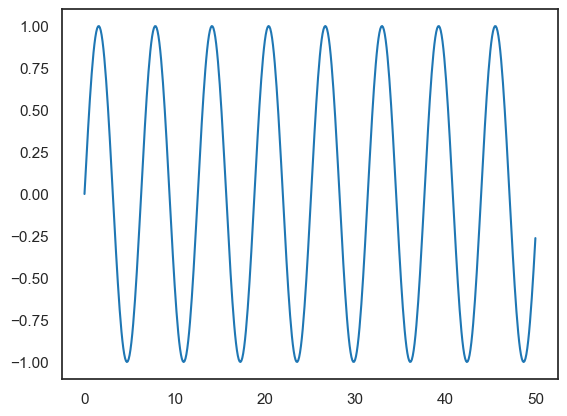

In [8]:
x = np.linspace(0, 50, 501)
y = np.sin(x)
plt.plot(x, y)

We will convert this into a data frame for convenience.


In [9]:
df = pd.DataFrame(data=y, index=x, columns=['Sine'])

We are dealing with a univariate time series, so we have a total of one feature. We will be using 10% of the simulated data for testing.


In [10]:
# percentage of data used for testing
test_percent = 0.1
# number of features
n_features = 1
# sequence length
length = 50
# batch size 
batch_size = 1

Let us now create a training and testing dataset to train and test our model on.


In [11]:
test_point = np.round(len(df)*test_percent)
test_ind = int(len(df)-test_point)

train = df.iloc[:test_ind]
test = df.iloc[test_ind:]

We will perform some basic preprocessing using the `MinMaxScaler`, which normalizes the input.


In [12]:
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train)
scaled_test = scaler.transform(test)

`TimeseriesGenerator` is a utility class by Keras that is used in generating batches of temporal data. Given our scaled training data, we create 401 output sequences.


In [13]:
generator = TimeseriesGenerator(scaled_train, scaled_train, length=length, batch_size=batch_size)
len(generator)

401

We will use the `LSTM()` layer with 50 units, and an input shape defined by the sequence length and number of features.


In [14]:
model = Sequential()

model.add(LSTM(50, input_shape=(length, n_features)))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

In [16]:
model.fit(generator, epochs=6)

Epoch 1/6
401/401 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0194
Epoch 2/6
401/401 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 3.6797e-04
Epoch 3/6
401/401 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0013
Epoch 4/6
401/401 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 7.6313e-05
Epoch 5/6
401/401 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 3.3976e-04
Epoch 6/6
401/401 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 6.9389e-05


In [17]:
forecast = []

first_eval_batch = scaled_train[-length:]
current_batch = first_eval_batch.reshape((1, length, n_features))

for i in range(25):
    current_pred = model.predict(current_batch)[0]
    forecast.append(current_pred)
    current_batch = np.append(current_batch[:, 1:, :], [[current_pred]], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


We will invert the min-max scaling on the predictions to allow for a direct comparison with the ground truth.


In [18]:
forecast = scaler.inverse_transform(forecast)

In [19]:
forecast_index = np.arange(50.1, 52.6, step=0.1)

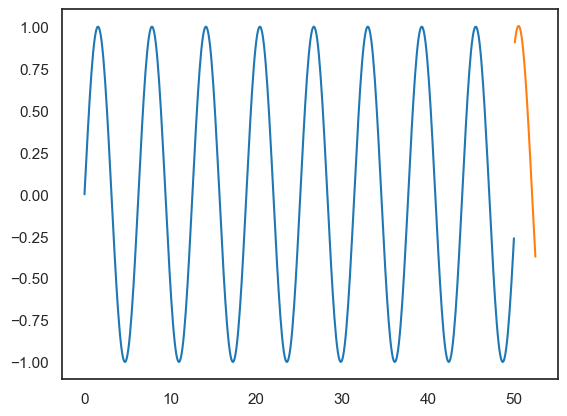

In [20]:
plt.plot(df.index, df['Sine'])
plt.plot(forecast_index, forecast)

In [21]:
# Hyperparameters
num_words = 10000
maxlen = 1000
test_split = 0.3

In [23]:
from tensorflow.keras.datasets import reuters

Next, we will use the Keras API to load in our reuters dataset.


In [24]:
# Load reuters Data from Keras datasets
(X_train, y_train),(X_test, y_test) = reuters.load_data(num_words=num_words, test_split=0.3)
print(len(X_train), 'train sequences')
print(len(X_test), 'test sequences')

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
7859 train sequences
3369 test sequences


In terms of pre-processing, we pad sequences to the same length using `pad_sequences`. Sequences longer than `num_timesteps` are truncated so that they fit the desired length. Whereas sequences that are shorter than `num_timesteps` are padded with value until they are `num_timesteps` long.


In [25]:
# data preprocessing
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)


y_train = tf.keras.utils.to_categorical(y_train, 46)
y_test = tf.keras.utils.to_categorical(y_test, 46)

X_train shape: (7859, 1000)
X_test shape: (3369, 1000)


Start by defining the model architecture. Use a `GRU` layer with 128 units, and a dropout rate of 0.2. Use a dense layer with 46 units and softmax as the activation function. Print out the model summary.


In [27]:

from tensorflow.keras import Input

model = Sequential()
model.add(Input(shape=(1000,)))          # <-- explicit input layer
model.add(Embedding(input_dim=num_words, output_dim=300))
model.add(GRU(128, dropout=0.2))
model.add(Dense(46, activation='softmax'))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 1000, 300)      │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │       165,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 46)             │         5,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,171,054 (12.10 MB)

 Trainable params: 3,171,054 (12.10 MB)

 Non-trainable params: 0 (0.00 B)

Now compile the model using categorical_crossentropy as the loss function, adam as the optimizer and accuracy as the metric. Train the model using 256 as the batch size, over 10 training iterations and using 20% of the data for validation purposes. Finally, evaluate the model's performance on the test dataset.


In [28]:

model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
model.fit(X_train, y_train,batch_size=256,epochs=10,validation_split=0.2)
model.evaluate(X_test,y_test)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 114s 4s/step - accuracy: 0.3210 - loss: 2.9349 - val_accuracy: 0.3950 - val_loss: 2.3455
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 169s 7s/step - accuracy: 0.4136 - loss: 2.1724 - val_accuracy: 0.4860 - val_loss: 1.9914
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 219s 9s/step - accuracy: 0.4918 - loss: 1.9037 - val_accuracy: 0.5108 - val_loss: 1.8163
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 243s 10s/step - accuracy: 0.5530 - loss: 1.7059 - val_accuracy: 0.5598 - val_loss: 1.7032
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 257s 10s/step - accuracy: 0.5810 - loss: 1.6000 - val_accuracy: 0.5541 - val_loss: 1.7475
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 228s 9s/step - accuracy: 0.6116 - loss: 1.5227 - val_accuracy: 0.5999 - val_loss: 1.6473
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 243s 10s/step - accuracy: 0.6496 - loss: 1.4254 - val_accuracy: 0.5992 - val_loss: 1.6292
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 372s 15s/step - accuracy: 0.6630 - loss: 1.3778 - val_accuracy: 0.5916

[1.6119487285614014, 0.619768500328064]